In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Lab_Images/bai3_flip_horizontal.png")
print(f"Kích thước ảnh: {img.size}")
img_with_text = img.copy()
draw = ImageDraw.Draw(img_with_text)

# Tạo font (dùng font mặc định vì Colab không có arial.ttf)
font_large = ImageFont.load_default()
font_small = ImageFont.load_default()

# Thêm tiêu đề màu trắng
draw.text((50, 50), "THỊ GIÁC MÁY TÍNH", font=font_large, fill=(255, 255, 255))
# Thêm phụ đề màu vàng
draw.text((50, 100), "Computer Vision Course", font=font_small, fill=(255, 255, 0))

img_with_text.save("/content/bai8_with_text.png")
print("✓ Đã thêm text lên ảnh")


Kích thước ảnh: (400, 267)
✓ Đã thêm text lên ảnh


In [ ]:
img_watermark = img.copy()

# Tạo layer trong suốt với chế độ RGBA
watermark = Image.new('RGBA', img.size, (0, 0, 0, 0))
watermark_draw = ImageDraw.Draw(watermark)

# Tạo text watermark
watermark_text = "© 2024 Computer Vision Lab"
text_width = watermark_draw.textlength(watermark_text, font=font_small)

# Đặt ở góc dưới phải
x = img.width - text_width - 20
y = img.height - 40

# Text màu trắng với độ trong suốt 128/255
watermark_draw.text((x, y), watermark_text, font=font_small, fill=(255, 255, 255, 128))

# Ghép watermark với ảnh gốc
img_rgba = img_watermark.convert('RGBA')
img_with_watermark = Image.alpha_composite(img_rgba, watermark)
img_with_watermark = img_with_watermark.convert('RGB')

img_with_watermark.save("/content/bai8_watermark.jpg")
print("✓ Đã thêm watermark trong suốt")


✓ Đã thêm watermark trong suốt


In [ ]:
img_with_logo = img.copy()
logo_draw = ImageDraw.Draw(img_with_logo)

# Thiết lập vị trí logo (góc trên phải)
logo_size = 80
logo_x = img.width - logo_size - 20
logo_y = 20

# Vẽ hình tròn màu đỏ viền trắng
logo_draw.ellipse([logo_x, logo_y, logo_x + logo_size, logo_y + logo_size],
                  fill=(255, 0, 0), outline=(255, 255, 255), width=3)

# Thêm text "CV" vào giữa logo
logo_text = "CV"
text_bbox = logo_draw.textbbox((0, 0), logo_text, font=font_small)
text_width = text_bbox[2] - text_bbox[0]
text_height = text_bbox[3] - text_bbox[1]

# Tính tọa độ để căn giữa
text_x = logo_x + (logo_size - text_width) // 2
text_y = logo_y + (logo_size - text_height) // 2

logo_draw.text((text_x, text_y), logo_text, font=font_small, fill=(255, 255, 255))
img_with_logo.save("/content/bai8_with_logo.png")
print("✓ Đã thêm logo")


✓ Đã thêm logo


In [ ]:
img_with_caption = img.copy()

# Tạo ảnh mới cao hơn để chứa caption
caption_height = 80
new_img = Image.new('RGB', (img.width, img.height + caption_height), (0, 0, 0))
new_img.paste(img, (0, 0))  # Dán ảnh gốc lên trên

caption_draw = ImageDraw.Draw(new_img)
caption_text = "Hình ảnh được xử lý bằng Python PIL"

# Căn giữa text
text_bbox = caption_draw.textbbox((0, 0), caption_text, font=font_small)
text_width = text_bbox[2] - text_bbox[0]
text_x = (new_img.width - text_width) // 2
text_y = img.height + 20

caption_draw.text((text_x, text_y), caption_text, font=font_small, fill=(255, 255, 255))
new_img.save("/content/bai8_with_caption.png")
print("✓ Đã thêm caption")


✓ Đã thêm caption


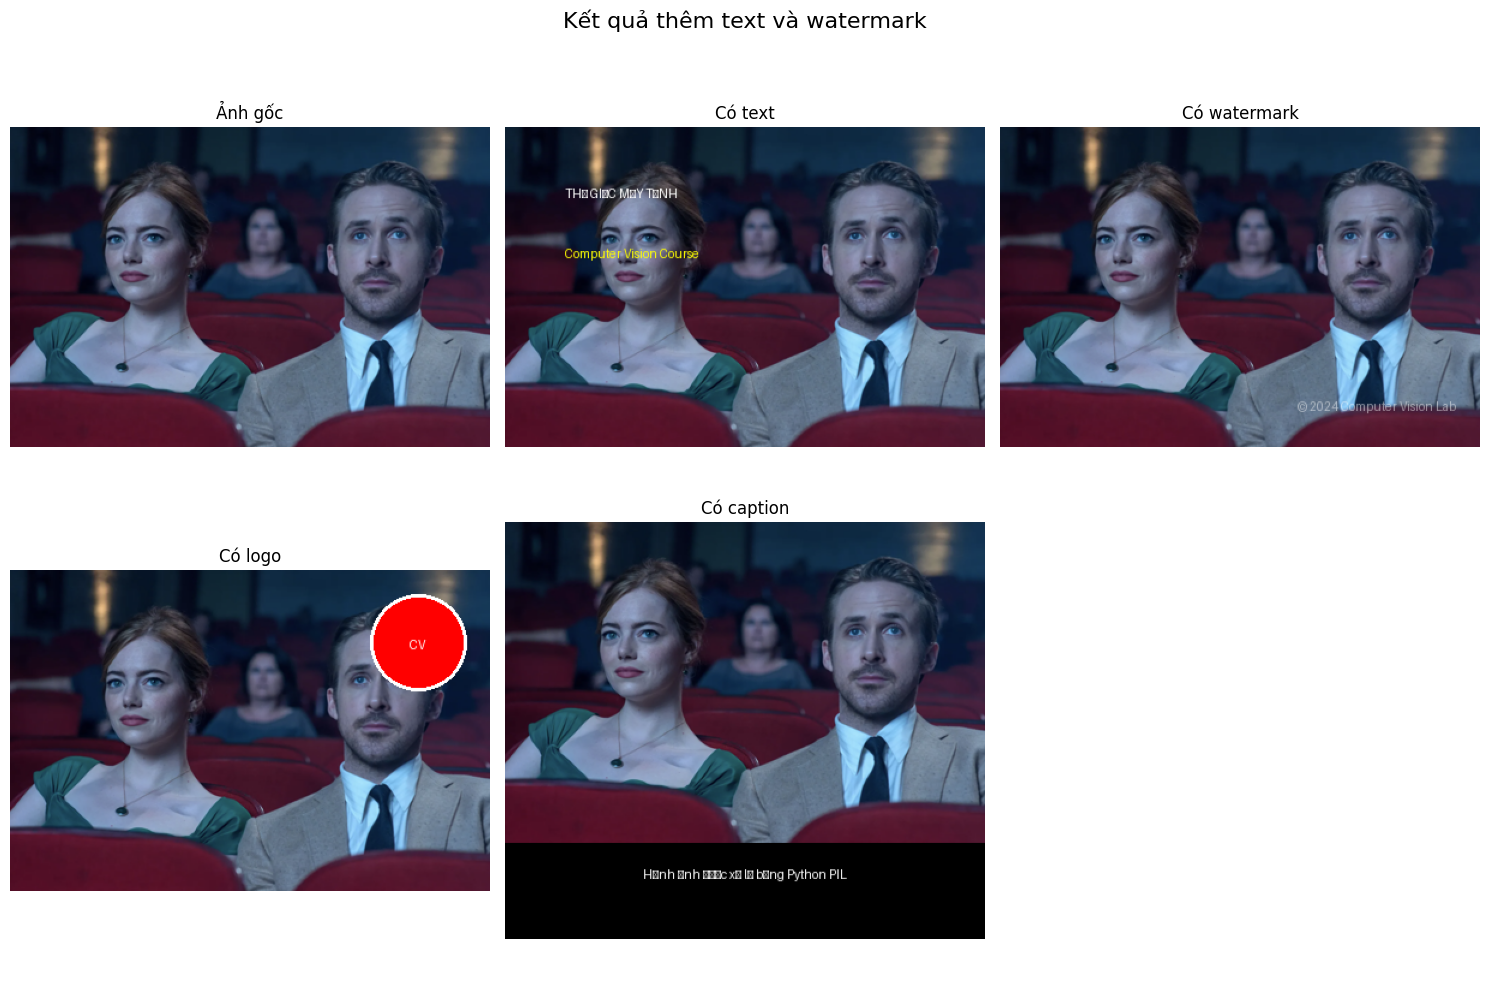

In [ ]:
# Tạo subplot để hiển thị tất cả kết quả
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Kết quả thêm text và watermark', fontsize=16)

images = [img, img_with_text, img_with_watermark, img_with_logo, new_img]
titles = ['Ảnh gốc', 'Có text', 'Có watermark', 'Có logo', 'Có caption']

for i, (image, title) in enumerate(zip(images, titles)):
    if i < 3:
        row, col = 0, i
    else:
        row, col = 1, i-3

    axes[row, col].imshow(image)
    axes[row, col].set_title(title, fontsize=12)
    axes[row, col].axis('off')

# Ẩn ô trống cuối
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
